### Imports

In [1]:
import warnings
from pathlib import Path

import torch
import torch.nn as nn

from src.datasets.audio_dataset import AudioDataset
from src.engine import benchmark_cnn, train_one_epoch_cnn, validate_cnn, get_split_dataloaders
from src.models.cnn_2d_classifier import CNN2DClassifier
from src.preprocessing import get_cnn_pipeline
from src.utils import plot_training_history

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [2]:
INPUT_DIR = Path('../../data/audioMNIST')
MODEL_PATH = Path('../../models/cnn.pth')

# Hyperparameters
LR = 0.001
NUM_EPOCHS = 5

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Training Script

Features shape: torch.Size([64, 1, 64, 27])
Labels shape: torch.Size([64])

Training CNN...
[Epoch 1/5]


Validating: 100%|██████████| 47/47 [00:04<00:00, 10.59batches/s]


Train Loss: 0.48 | Train Accuracy: 88.69% | Val Loss: 0.10 | Val Accuracy: 97.87%

[Epoch 2/5]


Validating: 100%|██████████| 47/47 [00:01<00:00, 36.64batches/s]


Train Loss: 0.06 | Train Accuracy: 98.80% | Val Loss: 0.05 | Val Accuracy: 99.03%

[Epoch 3/5]


...

Train Loss: 0.02 | Train Accuracy: 99.62% | Val Loss: 0.02 | Val Accuracy: 99.40%

[Epoch 5/5]


Validating: 100%|██████████| 47/47 [00:01<00:00, 40.06batches/s]


Train Loss: 0.01 | Train Accuracy: 99.76% | Val Loss: 0.02 | Val Accuracy: 99.47%

Best model had an accuracy of 99.47%.
Running final test...

Benchmarking: 100%|██████████| 47/47 [00:01<00:00, 38.38batches/s]


Test accuracy: 99.57% | Total MACs: 694778


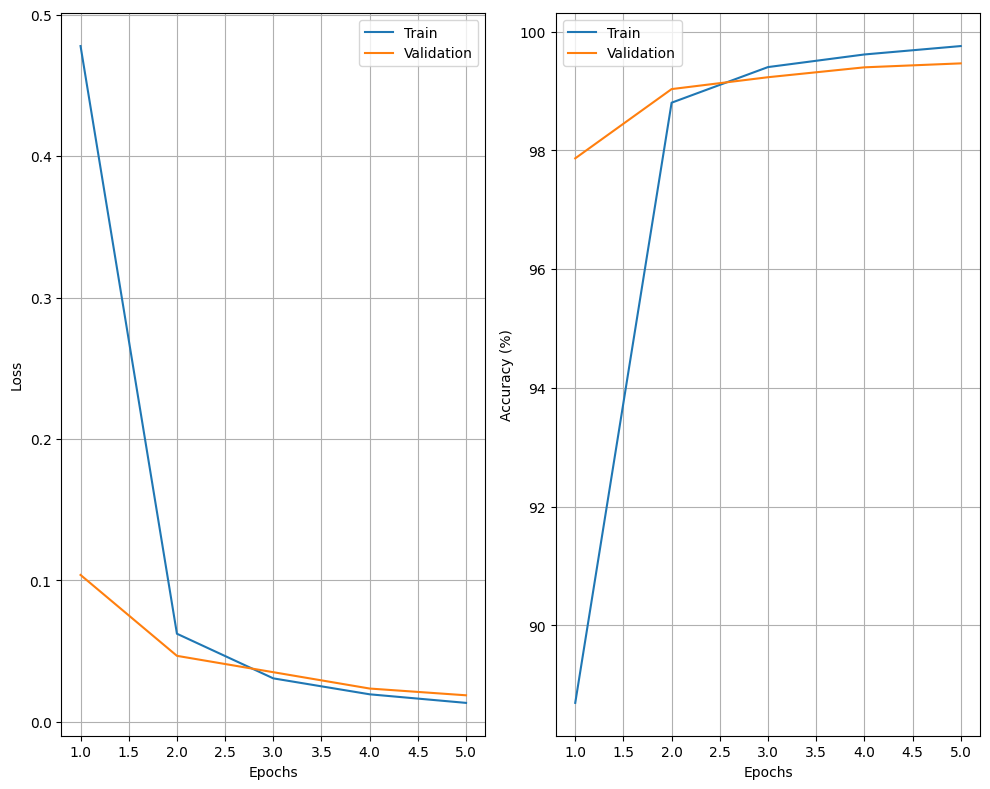

In [4]:
# TODO: Hyperparameter sweeping
# TODO: Seed for fair comparison
if __name__ == '__main__':
    dataset = AudioDataset(input_dir=INPUT_DIR, pipeline=get_cnn_pipeline())
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Train the model
    model = CNN2DClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # Keep track of best model
    print('Training CNN...')
    best_accuracy = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(NUM_EPOCHS):
        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')

        train_loss, train_acc = train_one_epoch_cnn(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate_cnn(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc:.2f}%')
        print()

    print(f'Best model had an accuracy of {best_accuracy:.2f}%.')
    print(f'Running final test...', end='')
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint, strict=True)
    model.to(device)

    test_accuracy, macs = benchmark_cnn(device, model, test_dataloader)
    print(f'Test Accuracy: {test_accuracy:.2f}% | Total MACs: {macs}')
    plot_training_history(train_losses, train_accs, val_losses, val_accs)